In [ ]:
###

In [28]:
# Cell 1: Imports & settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries loaded.")


Libraries loaded.


In [29]:
# Cell 2: Load dataset (update path if needed) and basic cleaning
file_path = "../Data/disease_diagnosis.csv"   # <-- update if different
df = pd.read_csv(file_path)
print("Loaded:", file_path, "shape:", df.shape)

# Split Blood_Pressure_mmHg into numeric columns if present
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].astype(str).str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)

df.info()


Loaded: ../Data/disease_diagnosis.csv shape: (2000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Heart_Rate_bpm       2000 non-null   int64  
 4   Body_Temperature_C   2000 non-null   float64
 5   Oxygen_Saturation_%  2000 non-null   float64
 6   Symptom_1            2000 non-null   object 
 7   Symptom_2            1713 non-null   object 
 8   Symptom_3            1629 non-null   object 
 9   Severity             1580 non-null   object 
 10  Treatment_Plan       1580 non-null   object 
 11  Diagnosis            2000 non-null   object 
 12  Systolic_BP          2000 non-null   int64  
 13  Diastolic_BP         2000 non-null   int64  
dtypes: float64(2), int64(5), object(

In [30]:
# Cell 3: Consolidate symptom columns into multi-hot representation
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3']
df['All_Symptoms'] = df[symptom_cols].apply(lambda row: [s for s in row if pd.notna(s)], axis=1)
mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df['All_Symptoms'])
symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_, index=df.index)
df = pd.concat([df, symptom_df], axis=1)
df.drop(columns=symptom_cols + ['All_Symptoms'], inplace=True)

print(f"Created {len(mlb.classes_)} symptom features.")
print("Example columns:", list(mlb.classes_)[:10])

joblib.dump(mlb, "symptom_binarizer.joblib")
print("Symptom binarizer saved to symptom_binarizer.joblib")

Created 8 symptom features.
Example columns: ['Body ache', 'Cough', 'Fatigue', 'Fever', 'Headache', 'Runny nose', 'Shortness of breath', 'Sore throat']
Symptom binarizer saved to symptom_binarizer.joblib


In [31]:
# Cell 4: Define X, y and train/test split
y = df["Diagnosis"]
X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"], errors='ignore')

# List feature types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
# Symptom features (binary) - they are numeric; keep them out of scaling if desired
symptom_cols_generated = list(mlb.classes_)
numeric_cols_no_symptoms = [c for c in numeric_cols if c not in symptom_cols_generated]

print("Numeric (no symptoms):", numeric_cols_no_symptoms)
print("Categorical:", categorical_cols)
print("Symptom columns (count):", len(symptom_cols_generated))

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Numeric (no symptoms): ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
Categorical: ['Gender']
Symptom columns (count): 8
Train shape: (1600, 15) Test shape: (400, 15)


In [32]:
# Cell 5: Preprocessors tailored to each model

# 1) Logistic Regression: scale numeric features, OHE categorical, pass symptoms untouched
preprocessor_lr = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")  # symptom columns passed through

# 2) Random Forest: impute numeric, do NOT scale (tree-based). OHE categorical, pass symptoms
preprocessor_rf = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

# 3) LightGBM: LightGBM can accept numeric features; use imputer but avoid scaling. We will OHE categorical as well.
preprocessor_lgb = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_cols)
], remainder="passthrough")

print("Preprocessors defined.")


Preprocessors defined.


In [33]:
# Cell 6: Model pipelines and hyperparameter grids
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
n_jobs = -1
scoring = "f1_weighted"

# Logistic Regression pipeline & grid
pipe_lr = Pipeline([("preprocessor", preprocessor_lr), ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced'))])
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 5.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["saga"]  # saga supports multinomial with l2 and class_weight
}

# Random Forest pipeline & grid
pipe_rf = Pipeline([("preprocessor", preprocessor_rf), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))])
param_grid_rf = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 10, 25],
    "clf__min_samples_leaf": [1, 3, 6]
}

# LightGBM pipeline & grid
pipe_lgb = Pipeline([("preprocessor", preprocessor_lgb), ("clf", lgb.LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced'))])
param_grid_lgb = {
    "clf__num_leaves": [31, 63],
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.05, 0.1]
}

grids = {
    "LogisticRegression": (pipe_lr, param_grid_lr),
    "RandomForest": (pipe_rf, param_grid_rf),
    "LightGBM": (pipe_lgb, param_grid_lgb)
}
print("Pipelines and parameter grids ready.")


Pipelines and parameter grids ready.


2025/10/02 12:45:19 INFO mlflow.tracking.fluent: Experiment with name 'Healthcare_Models_Experiment' does not exist. Creating a new experiment.



=== Tuning and training: LogisticRegression ===
Fitting 4 folds for each of 4 candidates, totalling 16 fits
Best params for LogisticRegression: {'clf__C': 5.0, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Best CV f1_weighted: 0.9104560039833002

Classification Report for LogisticRegression (test set):

              precision    recall  f1-score   support

  Bronchitis       0.90      0.88      0.89        80
        Cold       0.92      0.93      0.92        84
         Flu       0.97      0.89      0.93        82
     Healthy       0.92      0.93      0.92        84
   Pneumonia       0.87      0.96      0.91        70

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.91       400
weighted avg       0.92      0.92      0.92       400



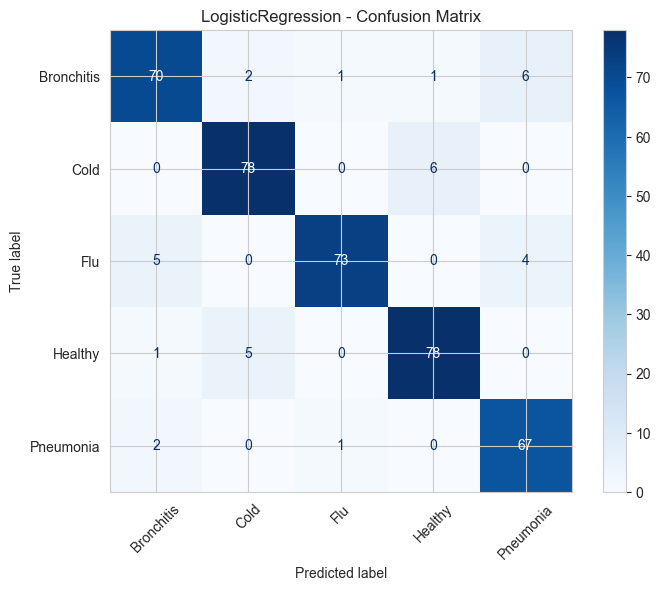

2025/10/02 12:45:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/02 12:46:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged LogisticRegression model to MLflow
Saved best pipeline to best_pipeline_LogisticRegression.joblib

=== Tuning and training: RandomForest ===
Fitting 4 folds for each of 18 candidates, totalling 72 fits
Best params for RandomForest: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
Best CV f1_weighted: 0.8877787136537565

Classification Report for RandomForest (test set):

              precision    recall  f1-score   support

  Bronchitis       0.85      0.85      0.85        80
        Cold       0.89      0.81      0.85        84
         Flu       0.96      0.89      0.92        82
     Healthy       0.81      0.94      0.87        84
   Pneumonia       0.87      0.89      0.88        70

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



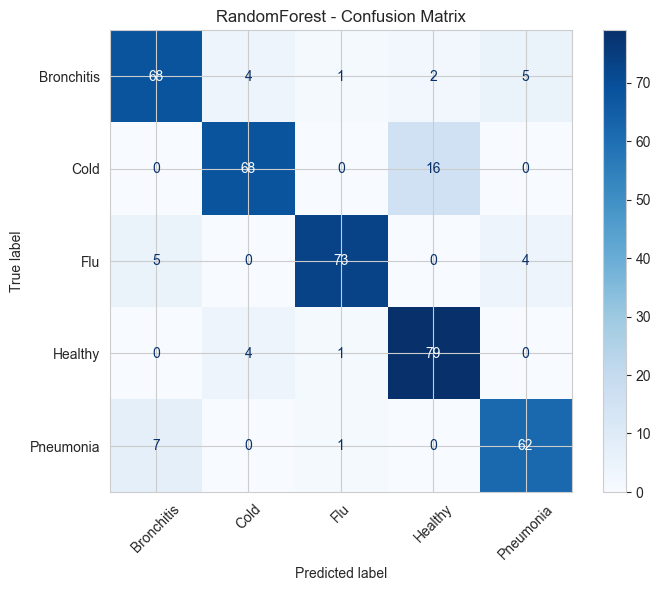

2025/10/02 12:46:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/02 12:46:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged RandomForest model to MLflow
Saved best pipeline to best_pipeline_RandomForest.joblib

=== Tuning and training: LightGBM ===
Fitting 4 folds for each of 8 candidates, totalling 32 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

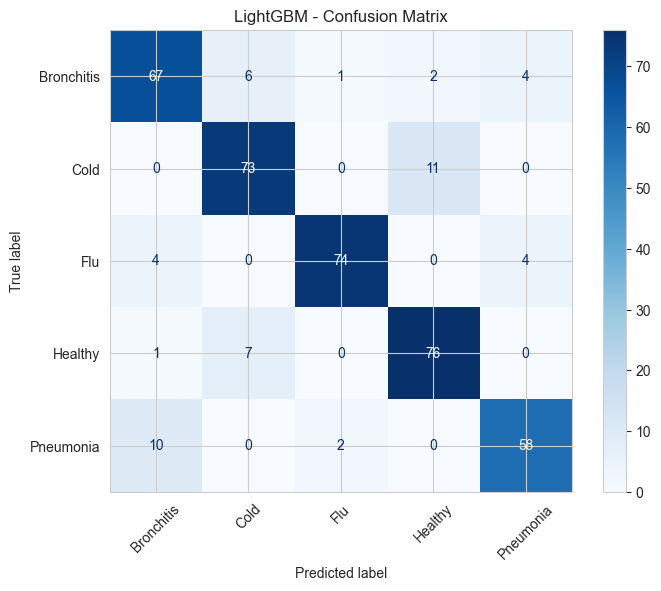

2025/10/02 12:47:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/02 12:47:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged LightGBM model to MLflow
Saved best pipeline to best_pipeline_LightGBM.joblib


In [34]:
import mlflow
import mlflow.sklearn
import pandas as pd

# Set experiment name
mlflow.set_experiment("Healthcare_Models_Experiment")

results = {}

for name, (pipeline, param_grid) in grids.items():
    print(f"\n=== Tuning and training: {name} ===")
    
    # Start MLflow run
    with mlflow.start_run(run_name=name):
        gs = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            verbose=1,
            return_train_score=True
        )
        gs.fit(X_train, y_train)

        print(f"Best params for {name}:", gs.best_params_)
        print(f"Best CV {scoring}:", gs.best_score_)
        
        # Log best hyperparameters and best CV score
        mlflow.log_params(gs.best_params_)
        mlflow.log_metric("best_cv_score", gs.best_score_)
        
        # Log all candidate hyperparameters and CV scores
        cv_results_df = pd.DataFrame(gs.cv_results_)
        # Save candidate results to CSV and log as artifact
        cv_results_csv = f"{name}_cv_results.csv"
        cv_results_df.to_csv(cv_results_csv, index=False)
        mlflow.log_artifact(cv_results_csv)
        
        # Evaluate on test set
        best_pipeline = gs.best_estimator_
        y_pred = best_pipeline.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        print(f"\nClassification Report for {name} (test set):\n")
        print(classification_report(y_test, y_pred))
        
        # Log test metrics
        for label, metrics in report.items():
            if label not in ["accuracy", "macro avg", "weighted avg"]:
                mlflow.log_metrics({f"{label}_{k}": v for k, v in metrics.items()})
        mlflow.log_metric("accuracy", report["accuracy"])
        
        # Confusion matrix plot
        labels = best_pipeline.named_steps['clf'].classes_
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        fig, ax = plt.subplots(figsize=(8,6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues, ax=ax)
        plt.title(f"{name} - Confusion Matrix")
        plt.xticks(rotation=45)
        plt.show()
        
        # Log model
        mlflow.sklearn.log_model(best_pipeline, artifact_path="model")
        print(f"Logged {name} model to MLflow")
        
        # Save locally as before
        joblib.dump(best_pipeline, f"best_pipeline_{name}.joblib")
        print(f"Saved best pipeline to best_pipeline_{name}.joblib")
        
        # Save results in dict
        results[name] = {
            "grid_search": gs,
            "best_pipeline": best_pipeline,
            "test_report": report,
            "cv_results_df": cv_results_df
        }



In [35]:
# Cell 8: Quick summary table of test f1 (weighted) for each model
summary = []
for name, res in results.items():
    report_dict = res["test_report"]
    weighted_f1 = report_dict.get("weighted avg", {}).get("f1-score", None)
    accuracy = report_dict.get("accuracy", None)
    summary.append({"model": name, "weighted_f1": weighted_f1, "accuracy": accuracy})

summary_df = pd.DataFrame(summary).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(summary_df)

,model,weighted_f1,accuracy
0,LogisticRegression,0.915068,0.915
1,RandomForest,0.875146,0.875
2,LightGBM,0.870376,0.870


In [1]:
import pandas as pd
import joblib

# --- Load the saved artifacts ---
# IMPORTANT: Make sure these filenames match the files you saved.
# If your best model was RandomForest, change the model_path accordingly.
model_path = 'best_pipeline_LogisticRegression.joblib'
mlb_path = 'symptom_binarizer.joblib'

try:
    loaded_pipeline = joblib.load(model_path)
    loaded_mlb = joblib.load(mlb_path)
    print(f"Successfully loaded model pipeline from: '{model_path}'")
    print(f"Successfully loaded symptom binarizer from: '{mlb_path}'")
except FileNotFoundError as e:
    print(f"ERROR: Could not load model files. Make sure they are in the same directory as your notebook.")
    print(e)

Successfully loaded model pipeline from: 'best_pipeline_LogisticRegression.joblib'
Successfully loaded symptom binarizer from: 'symptom_binarizer.joblib'


In [2]:
def predict_diagnosis(patient_data: dict, model_pipeline, symptom_binarizer):
    """
    Takes a dictionary of patient data, preprocesses it, and returns a diagnosis.
    
    Args:
        patient_data (dict): A dictionary containing patient vitals and a list of symptoms.
        model_pipeline: The loaded scikit-learn pipeline for the model.
        symptom_binarizer: The loaded MultiLabelBinarizer for symptoms.
        
    Returns:
        str: The predicted diagnosis.
    """
    
    # --- Preprocessing Steps ---
    
    # 1. Convert the input dictionary to a single-row pandas DataFrame
    df = pd.DataFrame([patient_data])
    
    # 2. Separate the list of symptoms from the main DataFrame
    if 'symptoms' not in df.columns:
         raise ValueError("'symptoms' field is missing from the input data.")
    symptoms = df.pop('symptoms')

    # 3. Transform symptoms using the loaded MultiLabelBinarizer
    symptom_encoded = symptom_binarizer.transform(symptoms)
    symptom_df = pd.DataFrame(symptom_encoded, columns=symptom_binarizer.classes_, index=df.index)

    # 4. Combine the main features with the encoded symptom features
    final_df = pd.concat([df, symptom_df], axis=1)
    
    # 5. Ensure the column order and presence matches the model's training data
    # This is a crucial safety step.
    required_features = model_pipeline.feature_names_in_
    for col in required_features:
        if col not in final_df.columns:
            final_df[col] = 0 # Add any missing symptom columns as 0
    final_df = final_df[required_features] # Enforce the correct order

    # --- Prediction Step ---
    
    # 6. Use the full pipeline to predict on the preprocessed data
    prediction = model_pipeline.predict(final_df)
    
    return prediction[0]

In [3]:
# --- Create Sample Patient Data ---
# This dictionary mimics the JSON data that would come from your frontend.
sample_patient = {
    'Age': 52,
    'Gender': 'Female',
    'Heart_Rate_bpm': 90,
    'Body_Temperature_C': 38.5,
    'Oxygen_Saturation_%': 94.0,
    'Systolic_BP': 140,
    'Diastolic_BP': 90,
    'symptoms': ['Cough', 'Fatigue', 'Nausea'] # Note: 'Nausea' might not be in your binarizer's vocabulary.
                                              # It's good to test with symptoms you know are in the list.
}

# Let's use a sample with known symptoms from your dataset for a better test
sample_patient_flu = {
    'Age': 52,
    'Gender': 'Female',
    'Heart_Rate_bpm': 90,
    'Body_Temperature_C': 38.5,
    'Oxygen_Saturation_%': 94.0,
    'Systolic_BP': 140,
    'Diastolic_BP': 90,
    'symptoms': ['Cough', 'Fever', 'Body ache'] 
}


# --- Run the Prediction ---
try:
    predicted_diagnosis = predict_diagnosis(
        patient_data=sample_patient_flu, 
        model_pipeline=loaded_pipeline, 
        symptom_binarizer=loaded_mlb
    )

    print("\n--- Prediction Result ---")
    print("Sample data for prediction:")
    # Display the sample data in a clean format
    display(pd.DataFrame([sample_patient_flu]))

    print(f"\nPredicted Diagnosis: {predicted_diagnosis}")

except NameError:
    print("\nERROR: Model artifacts not loaded. Please run the first cell successfully.")
except Exception as e:
    print(f"\nAn error occurred during prediction: {e}")


--- Prediction Result ---
Sample data for prediction:


,Age,Gender,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Systolic_BP,Diastolic_BP,symptoms
0,52,Female,90,38.5,94.0,140,90,"[Cough, Fever, Body ache]"



Predicted Diagnosis: Flu
